## Modeling with XGBoost
In our previous notebook, we successfully transformed our cleaned text and labels into a mathematical format. Our data now perfectly speaks the language of machine learning.

In this notebook, we will use a highly powerful machine learning algorithm. We will use our newly prepared data to train this model so it can learn the exact mathematical patterns that separate spam from normal messages. Once trained, we will immediately use it to generate predictions.

By the end of this notebook, we will have a fully trained model and its predictions.

In [1]:
import numpy as np
import scipy.sparse

X_path='X_features.npz'
y_path='y_encoded.npy'

X=scipy.sparse.load_npz(X_path)
y=np.load(y_path)

print(f'Features shape: {X.shape}')
print(f'Labels shape: {y.shape}')

Features shape: (5169, 3000)
Labels shape: (5169,)


In [2]:
X

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 37833 stored elements and shape (5169, 3000)>

## Splitting the Data
Before we teach our algorithm how to catch spam, we need to divide our dataset into two groups using a technique known as the holdout method. We will accomplish this using a standard 80 to 20 ratio.

We will feed `80%` of our text messages directly into the algorithm. This group is called the training split (`X_train` and `y_train`). This large chunk of data acts as a textbook, allowing the model to study thousands of examples and learn exactly what makes a message normal or spam.

We intentionally hold out the remaining `20%` to serve as a rigorous final exam. This group is known as the test split (represented as `X_test` and `y_test`).

In [3]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test=train_test_split(X,y,train_size=0.8,test_size=0.2,random_state=42)

## Modeling using XGBoost

XGBoost, which stands for `Extreme Gradient Boosting`. Instead of relying on a single massive equation, XGBoost uses a strategic approach called Boosting. It builds a `sequence of smaller models called decision trees`. The first tree analyzes the text data and inevitably makes mistakes. The algorithm then builds a second tree specifically to correct those errors, followed by a third to correct the second, and so on. By the end of training, `these sequential trees combine` into one highly accurate spam detection model.

To understand why this is so powerful, compare it to Bagging, or Bootstrap Aggregating. In a Bagging algorithm like a Random Forest, the `model builds hundreds of trees independently at the exact same time and simply averages their answers`. Because XGBoost learns sequentially from its past mistakes, it is often much more accurate for complex text classification.
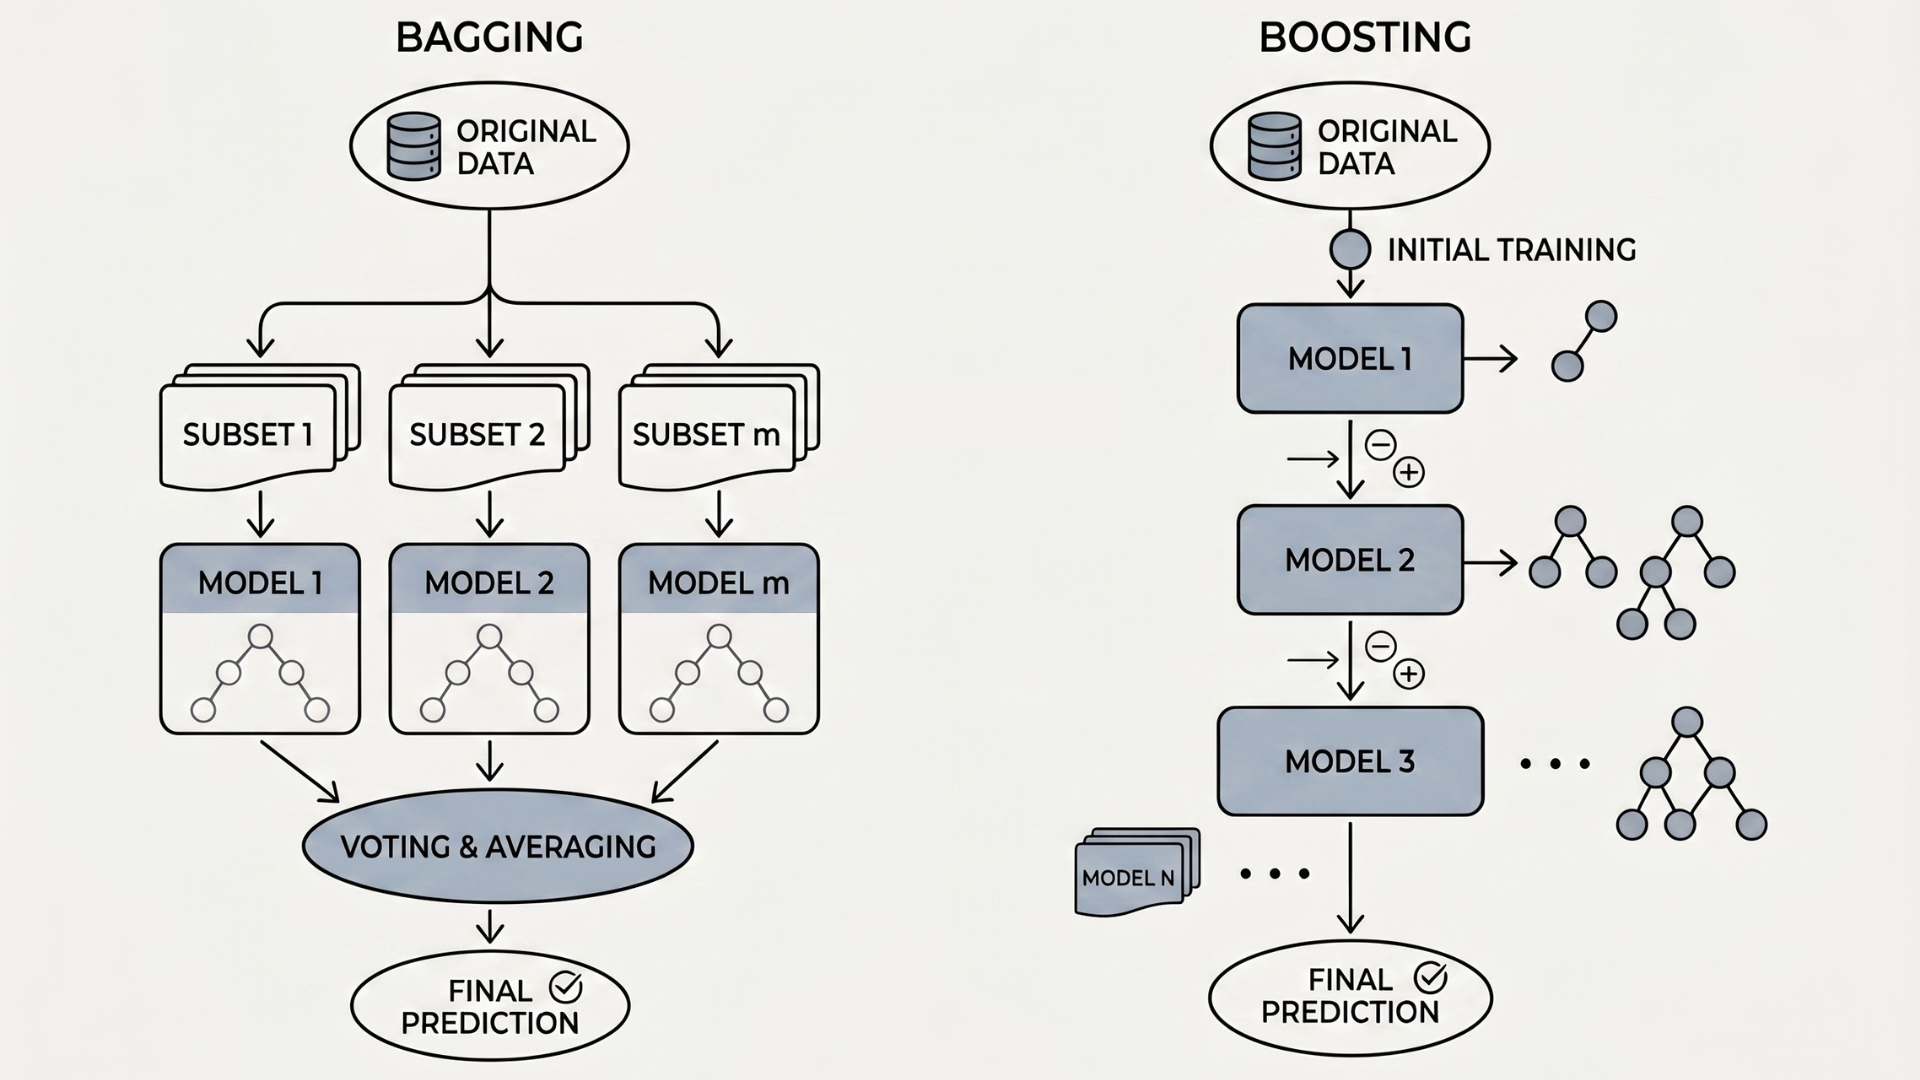

## Class Imbalance

In our first notebook, we saw that our data is heavily unbalanced. We have 4,516 normal messages but only 653 spam messages. Because there is so much normal text, a basic model might just take the easy way out and guess that every single message is normal.

To fix this, we use a setting called `scale positive weigh` and set it to 2. This simply gives the rare spam messages a louder voice, `telling the algorithm to treat every spam example as twice as important`. This ensures the model learns to catch spam without accidentally blocking your real emails. We also include a random state to guarantee our results are repeatable and set the evaluation metric to logloss to hide background warnings before we begin training.

Let's train the data using XGBoost using the code below.

In [4]:
from xgboost import XGBClassifier

model=XGBClassifier(scale_pos_weight=2,eval_metric='logloss',random_state=42)
# scale_pos_weight tells XGBoost: "when you get a positive-class (spam) example wrong, 
# treat that mistake as scale_pos_weight times more costly than getting 
# a ham example wrong." This pushes the model to pay disproportionately 
# more attention to correctly identifying spam, counteracting its natural 
# tendency to favor the majority class.

# eval_metric is exactly that: it tells XGBoost what number to calculate and watch 
# as it builds each tree, 
# to judge "is this model getting better or worse.

# Train the model
model.fit(X_train,y_train)

,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,None
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'logloss'
,feature_types feature_types: typing.Sequence[str] | None.. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


## Making Predictions

In [5]:
y_pred=model.predict(X_test)

## Saving Our Model and Predictions
In the next cell, we will use a library called Joblib to save our trained XGBoost model. This process freezes the complex logic and decision trees our model just learned so we can load it instantly in the future without needing to retrain it.

joblib is a Python library for saving Python objects to disk, then loading them back later — specifically optimized for large objects like trained ML models (which often contain big arrays of numbers internally).

In [6]:
import joblib

# save the trained xgboost model
joblib.dump(model,'xgboost_spam_model.pkl')

# save predictions and actual answers
np.save('y_test.npy',y_test)
np.save('y_pred.npy',y_pred)